# OralVision - Oral Disease Image Classification
Custom CNN vs EfficientNetB0 vs MobileNetV2 vs ResNet50

Dataset: [Oral Diseases](https://www.kaggle.com/datasets/salmansajid05/oral-diseases) (Kaggle)

In [1]:
!pip install -q kaggle tensorflow scikit-learn seaborn

In [2]:
import os
from google.colab import files

print("Upload your kaggle.json file")
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
for fname in uploaded:
    os.rename(fname, '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

Upload your kaggle.json file


Saving kaggle.json to kaggle.json


In [3]:
!kaggle datasets download -d salmansajid05/oral-diseases -p /content/data --unzip

Dataset URL: https://www.kaggle.com/datasets/salmansajid05/oral-diseases
License(s): unknown
100% 235M/235M [00:12<00:00, 19.8MB/s]



In [4]:
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                      Dropout, BatchNormalization, GlobalAveragePooling2D, Input)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = '/content/data'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

## Load File Paths and Explore Classes
This dataset has messy internal structure: each disease folder contains its own random
subfolders (`preview`, `images`, `done`, `original dataset`, ...). We only use the
**top-level folder name** as the class label and recursively collect every image inside it,
regardless of how deep or how it's organized internally.

In [5]:
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp')

class_dirs = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
print("Top-level folders found:", class_dirs)

Top-level folders found: ['Calculus', 'Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset', 'Data caries', 'Gingivitis', 'Mouth Ulcer', 'Tooth Discoloration', 'hypodontia']


In [6]:
# Drop folders that bundle more than one disease together (e.g. "Caries_Gingivitis_ToothDiscoloration")
# since a single image there can't get one clean label for single-label classification.
DISEASE_KEYWORDS = ['calculus', 'caries', 'gingiv', 'tooth', 'discolor', 'ulcer', 'hypodont']

def keyword_hits(name):
    name_l = name.lower()
    return sum(1 for k in DISEASE_KEYWORDS if k in name_l)

excluded_dirs = [d for d in class_dirs if keyword_hits(d) > 1]
class_dirs = [d for d in class_dirs if d not in excluded_dirs]

if excluded_dirs:
    print("Excluded combined/ambiguous folders:", excluded_dirs)
print("Final classes used:", class_dirs)

Excluded combined/ambiguous folders: ['Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset', 'Tooth Discoloration']
Final classes used: ['Calculus', 'Data caries', 'Gingivitis', 'Mouth Ulcer', 'hypodontia']


In [7]:
import hashlib

def file_hash(path, chunk_size=65536):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while chunk := f.read(chunk_size):
            h.update(chunk)
    return h.hexdigest()

records = []
for cls in class_dirs:
    cls_path = os.path.join(DATA_DIR, cls)
    files = []
    for ext in IMG_EXTS:
        files.extend(glob.glob(os.path.join(cls_path, '**', f'*{ext}'), recursive=True))
        files.extend(glob.glob(os.path.join(cls_path, '**', f'*{ext.upper()}'), recursive=True))
    for f in files:
        records.append({'filepath': f, 'label': cls})

df = pd.DataFrame(records)
print(f"Total images before dedup: {len(df)}")

# Remove exact duplicate images (e.g. a "preview" copy identical to the original file)
df['hash'] = df['filepath'].apply(file_hash)
df = df.drop_duplicates(subset='hash').drop(columns='hash').reset_index(drop=True)

print(f"Total images after dedup: {len(df)}")
print(f"Classes: {sorted(df['label'].unique())}")
df['label'].value_counts()

Total images before dedup: 10303
Total images after dedup: 8649
Classes: ['Calculus', 'Data caries', 'Gingivitis', 'Mouth Ulcer', 'hypodontia']


,count
label,
Mouth Ulcer,2784
Data caries,2576
Gingivitis,1245
hypodontia,1215
Calculus,829


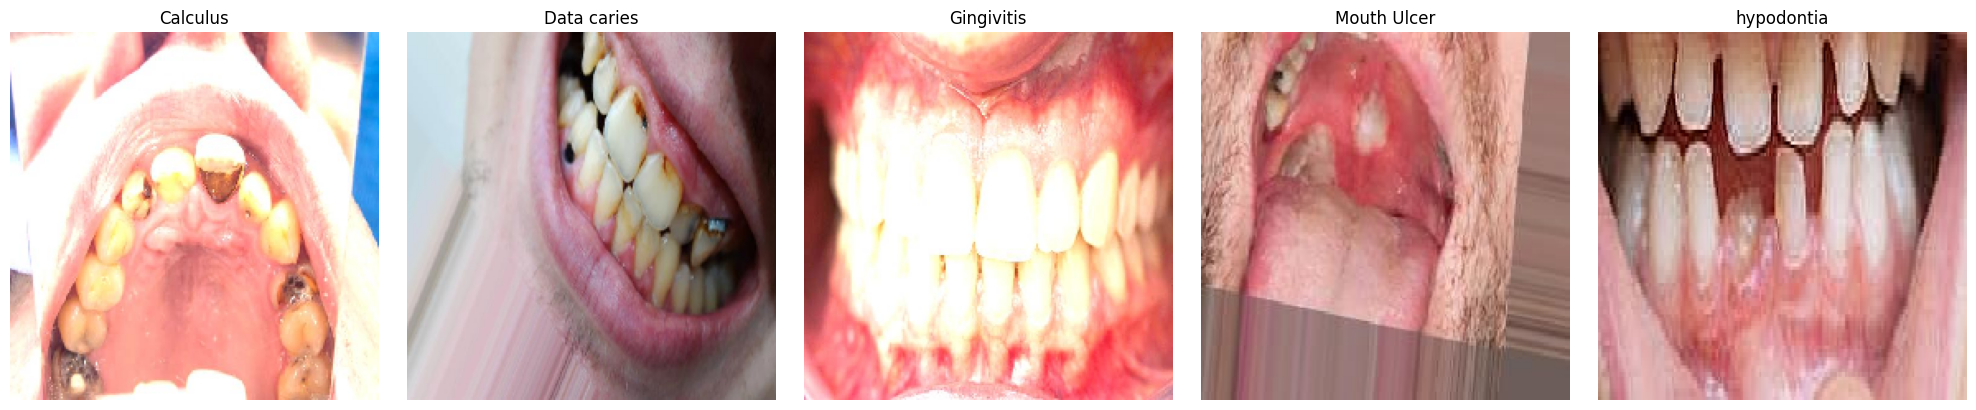

In [8]:
class_names = sorted(df['label'].unique())
num_classes = len(class_names)

fig, axes = plt.subplots(1, num_classes, figsize=(4 * num_classes, 4))
for ax, cls in zip(axes, class_names):
    sample_path = df[df['label'] == cls]['filepath'].sample(1, random_state=SEED).values[0]
    img = tf.keras.utils.load_img(sample_path, target_size=IMG_SIZE)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Preprocessing and Data Generators

In [9]:
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 6054 | Val: 1297 | Test: 1298


In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

def make_generator(datagen, dataframe, shuffle):
    return datagen.flow_from_dataframe(
        dataframe=dataframe,
        x_col='filepath',
        y_col='label',
        target_size=IMG_SIZE,
        class_mode='categorical',
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED
    )

train_gen = make_generator(train_datagen, train_df, shuffle=True)
val_gen = make_generator(val_test_datagen, val_df, shuffle=False)
test_gen = make_generator(val_test_datagen, test_df, shuffle=False)

Found 6054 validated image filenames belonging to 5 classes.
Found 1297 validated image filenames belonging to 5 classes.
Found 1298 validated image filenames belonging to 5 classes.


## Shared Training and Evaluation Helpers

In [11]:
results = {}

def train_model(model, name, epochs=25):
    checkpoint_path = f"/content/{name}_best.weights.h5"
    callbacks = [
        ModelCheckpoint(checkpoint_path, monitor='val_accuracy', mode='max',
                         save_best_only=True, save_weights_only=True, verbose=1),
        EarlyStopping(monitor='val_accuracy', mode='max', patience=6, restore_best_weights=True)
    ]
    history = model.fit(train_gen, validation_data=val_gen, epochs=epochs, callbacks=callbacks)
    model.load_weights(checkpoint_path)
    return history

def evaluate_model(model, name, history):
    test_gen.reset()
    loss, acc = model.evaluate(test_gen, verbose=0)
    preds = np.argmax(model.predict(test_gen), axis=1)
    y_true = test_gen.classes

    print(f"\n{name} - Test Accuracy: {acc:.4f} | Test Loss: {loss:.4f}")
    print(classification_report(y_true, preds, target_names=class_names))

    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history.history['accuracy'], label='train')
    ax[0].plot(history.history['val_accuracy'], label='val')
    ax[0].set_title(f"{name} Accuracy")
    ax[0].legend()
    ax[1].plot(history.history['loss'], label='train')
    ax[1].plot(history.history['val_loss'], label='val')
    ax[1].set_title(f"{name} Loss")
    ax[1].legend()
    plt.tight_layout()
    plt.show()

    results[name] = {'test_accuracy': acc, 'test_loss': loss}

## Model 1: Custom CNN (Built From Scratch)

In [12]:
def build_custom_cnn(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),

        Conv2D(32, 3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(),

        Conv2D(64, 3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(),

        Conv2D(128, 3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(),

        Conv2D(256, 3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

custom_cnn = build_custom_cnn((*IMG_SIZE, 3), num_classes)
custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,236,933 (50.49 MB)

 Trainable params: 13,235,973 (50.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [13]:
history_cnn = train_model(custom_cnn, "Custom_CNN")

Epoch 1/25
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.3904 - loss: 8.9126
Epoch 1: val_accuracy improved from None to 0.32151, saving model to /content/Custom_CNN_best.weights.h5

Epoch 1: finished saving model to /content/Custom_CNN_best.weights.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 110s 517ms/step - accuracy: 0.3968 - loss: 4.1496 - val_accuracy: 0.3215 - val_loss: 57.1404
Epoch 2/25
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.4568 - loss: 1.3226
Epoch 2: val_accuracy improved from 0.32151 to 0.49807, saving model to /content/Custom_CNN_best.weights.h5

Epoch 2: finished saving model to /content/Custom_CNN_best.weights.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 88s 459ms/step - accuracy: 0.4594 - loss: 1.2854 - val_accuracy: 0.4981 - val_loss: 7.7049
Epoch 3/25
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.4483 - loss: 1.2677
Epoch 3: val_accuracy did not improve from 0.49807
190/190 ━━━━━━━━━━━━━━━━━━━━ 86s 452ms/step - accuracy: 0.4534 - loss: 1.2254 - val_accu

41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step

Custom_CNN - Test Accuracy: 0.6980 | Test Loss: 0.8579
              precision    recall  f1-score   support

    Calculus       0.64      0.06      0.10       124
 Data caries       0.74      0.74      0.74       387
  Gingivitis       0.61      0.83      0.70       187
 Mouth Ulcer       0.90      0.73      0.80       418
  hypodontia       0.50      0.84      0.63       182

    accuracy                           0.70      1298
   macro avg       0.68      0.64      0.60      1298
weighted avg       0.73      0.70      0.68      1298



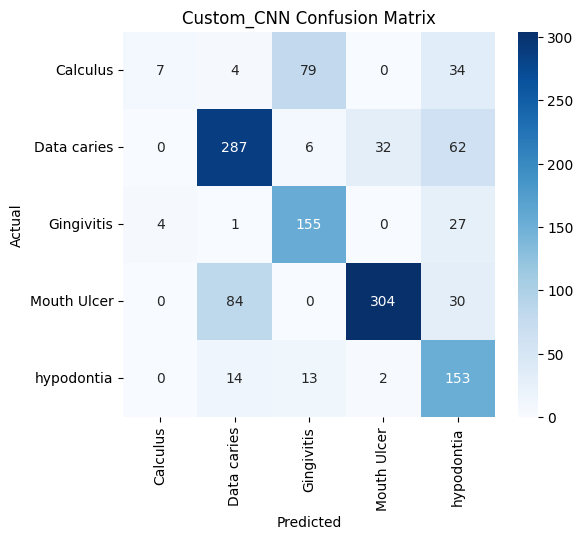

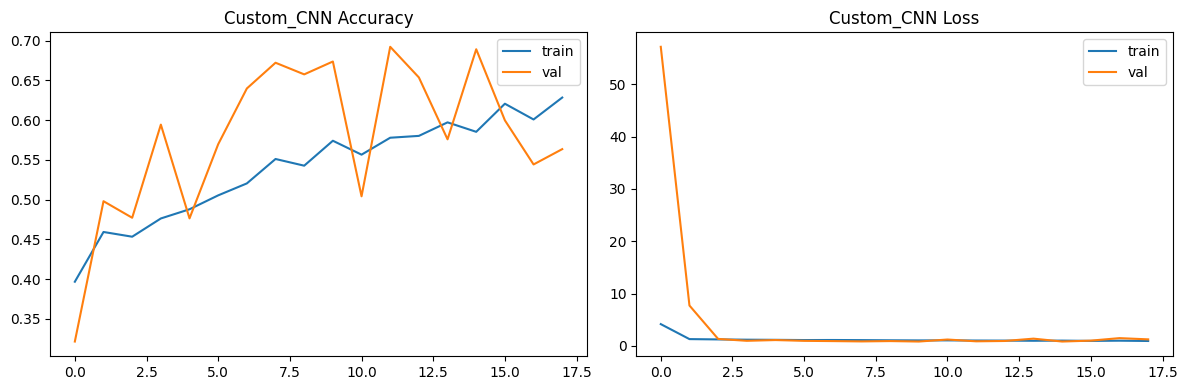

In [14]:
evaluate_model(custom_cnn, "Custom_CNN", history_cnn)

## Transfer Learning Models: EfficientNetB0, MobileNetV2, ResNet50

In [15]:
def build_transfer_model(base_model_class, input_shape, num_classes):
    base_model = base_model_class(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

### EfficientNetB0

In [16]:
efficientnet_model = build_transfer_model(EfficientNetB0, (*IMG_SIZE, 3), num_classes)
history_eff = train_model(efficientnet_model, "EfficientNetB0")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/25
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.3095 - loss: 1.5299
Epoch 1: val_accuracy improved from None to 0.29761, saving model to /content/EfficientNetB0_best.weights.h5

Epoch 1: finished saving model to /content/EfficientNetB0_best.weights.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 150s 641ms/step - accuracy: 0.3176 - loss: 1.5234 - val_accuracy: 0.2976 - val_loss: 1.5095
Epoch 2/25
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.3212 - loss: 1.5175
Epoch 2: val_accuracy improved from 0.29761 to 0.32151, saving model to /content/EfficientNetB0_best.weights.h5

Epoch 2: finished saving model to /content/EfficientNetB0_best.weights.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 88s 463ms/step - accuracy: 0.3178 - loss: 1.5140 - val_accuracy: 0.3215 - val_loss: 1.5079
Epoch 3/25
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.3075 - loss: 1.5099
Epoch 3: val_accuracy did not improve from 0.32151
190/190 ━━━━━━━━━━━━━━

41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 231ms/step

EfficientNetB0 - Test Accuracy: 0.3220 | Test Loss: 1.5068
              precision    recall  f1-score   support

    Calculus       0.00      0.00      0.00       124
 Data caries       0.00      0.00      0.00       387
  Gingivitis       0.00      0.00      0.00       187
 Mouth Ulcer       0.32      1.00      0.49       418
  hypodontia       0.00      0.00      0.00       182

    accuracy                           0.32      1298
   macro avg       0.06      0.20      0.10      1298
weighted avg       0.10      0.32      0.16      1298



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


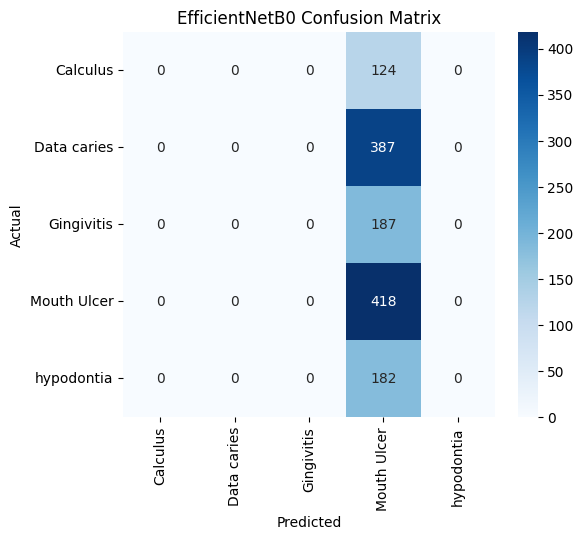

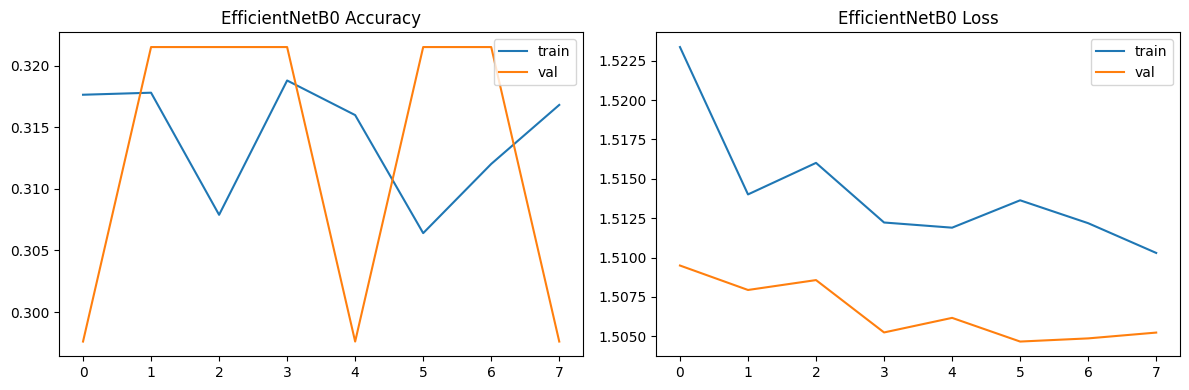

In [17]:
evaluate_model(efficientnet_model, "EfficientNetB0", history_eff)

### MobileNetV2

In [18]:
mobilenet_model = build_transfer_model(MobileNetV2, (*IMG_SIZE, 3), num_classes)
history_mob = train_model(mobilenet_model, "MobileNetV2")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/25
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.4658 - loss: 1.3569
Epoch 1: val_accuracy improved from None to 0.77795, saving model to /content/MobileNetV2_best.weights.h5

Epoch 1: finished saving model to /content/MobileNetV2_best.weights.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 124s 574ms/step - accuracy: 0.5833 - loss: 1.0600 - val_accuracy: 0.7779 - val_loss: 0.6237
Epoch 2/25
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.7286 - loss: 0.7082
Epoch 2: val_accuracy improved from 0.77795 to 0.81804, saving model to /content/MobileNetV2_best.weights.h5

Epoch 2: finished saving model to /content/MobileNetV2_best.weights.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 86s 450ms/step - accuracy: 0.7425 - loss: 0.6803 - val_accuracy: 0.8180 - val_loss: 0.5032
Epoch 3/25
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.7827 - loss: 0.5742
Epoch 3: val_accuracy improved from 0.81804 to 0.84888, saving model to /content/Mobile

41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 158ms/step

MobileNetV2 - Test Accuracy: 0.9214 | Test Loss: 0.2160
              precision    recall  f1-score   support

    Calculus       0.76      0.87      0.81       124
 Data caries       0.99      0.88      0.93       387
  Gingivitis       0.82      0.84      0.83       187
 Mouth Ulcer       0.99      0.98      0.99       418
  hypodontia       0.88      0.98      0.92       182

    accuracy                           0.92      1298
   macro avg       0.89      0.91      0.90      1298
weighted avg       0.93      0.92      0.92      1298



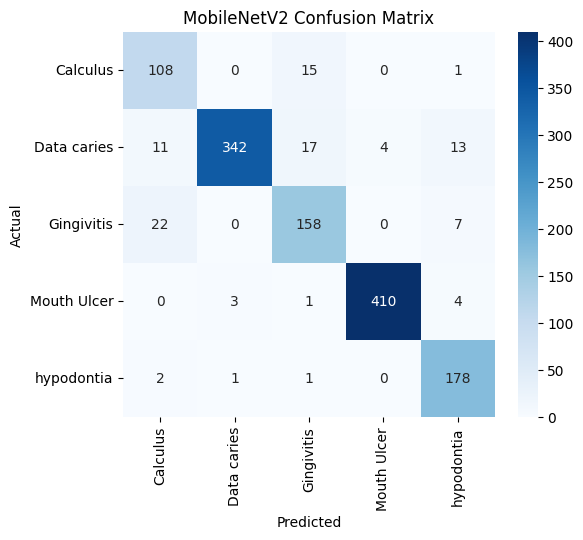

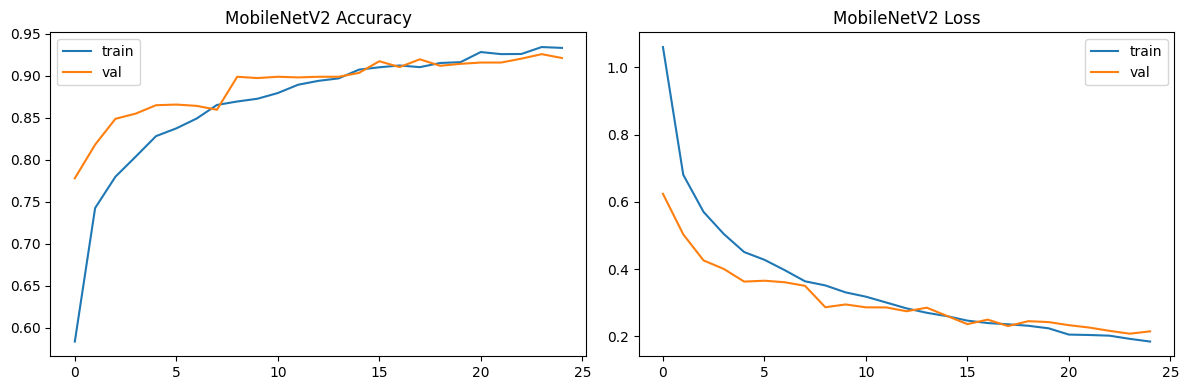

In [19]:
evaluate_model(mobilenet_model, "MobileNetV2", history_mob)

### ResNet50

In [20]:
resnet_model = build_transfer_model(ResNet50, (*IMG_SIZE, 3), num_classes)
history_res = train_model(resnet_model, "ResNet50")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/25
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.2737 - loss: 1.7399
Epoch 1: val_accuracy improved from None to 0.40170, saving model to /content/ResNet50_best.weights.h5

Epoch 1: finished saving model to /content/ResNet50_best.weights.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 118s 548ms/step - accuracy: 0.3034 - loss: 1.5967 - val_accuracy: 0.4017 - val_loss: 1.3793
Epoch 2/25
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.3722 - loss: 1.4232
Epoch 2: val_accuracy improved from 0.40170 to 0.47957, saving model to /content/ResNet50_best.weights.h5

Epoch 2: finished saving model to /content/ResNet50_best.weights.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 93s 487ms/step - accuracy: 0.3971 - loss: 1.3915 - val_accuracy: 0.4796 - val_loss: 1.2973
Epoch 3/25
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.4355 - loss: 1.3355
Epoch 3: val_accuracy improved from 0.47957 to 0.51735, saving model to /content/ResNet50_best.we

41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 173ms/step

ResNet50 - Test Accuracy: 0.5832 | Test Loss: 1.0537
              precision    recall  f1-score   support

    Calculus       0.77      0.08      0.15       124
 Data caries       0.49      0.70      0.57       387
  Gingivitis       0.53      0.47      0.50       187
 Mouth Ulcer       0.78      0.67      0.72       418
  hypodontia       0.54      0.60      0.57       182

    accuracy                           0.58      1298
   macro avg       0.62      0.50      0.50      1298
weighted avg       0.62      0.58      0.57      1298



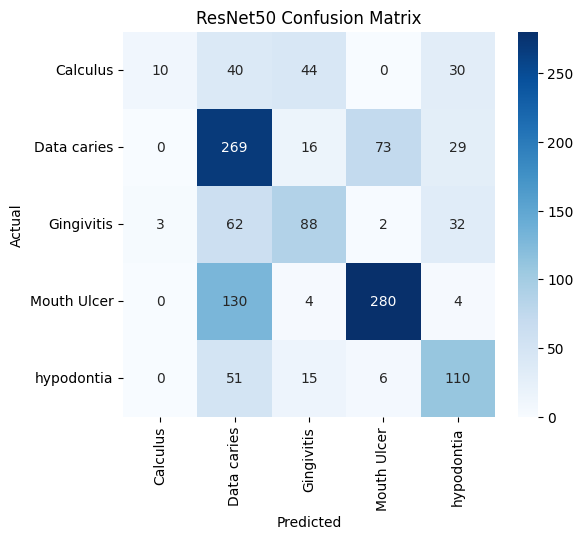

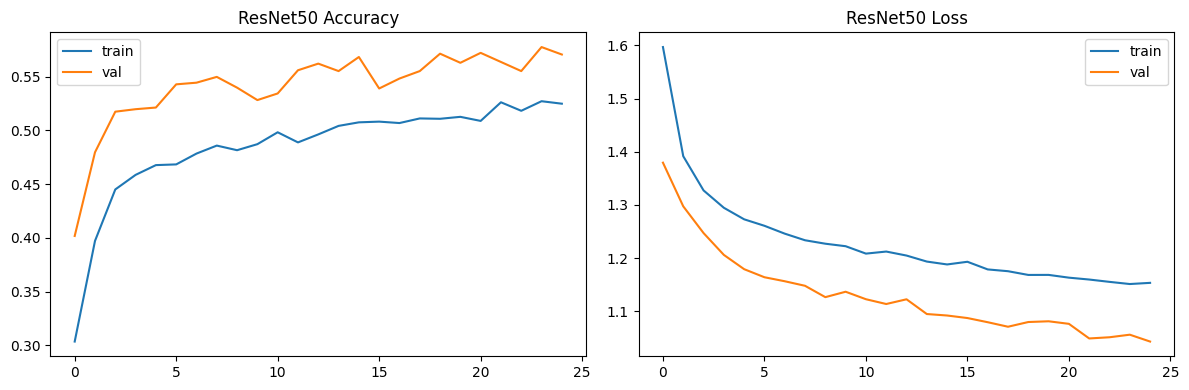

In [21]:
evaluate_model(resnet_model, "ResNet50", history_res)

## Final Comparison

                test_accuracy  test_loss
MobileNetV2          0.921418   0.216003
Custom_CNN           0.697997   0.857906
ResNet50             0.583205   1.053674
EfficientNetB0       0.322034   1.506824


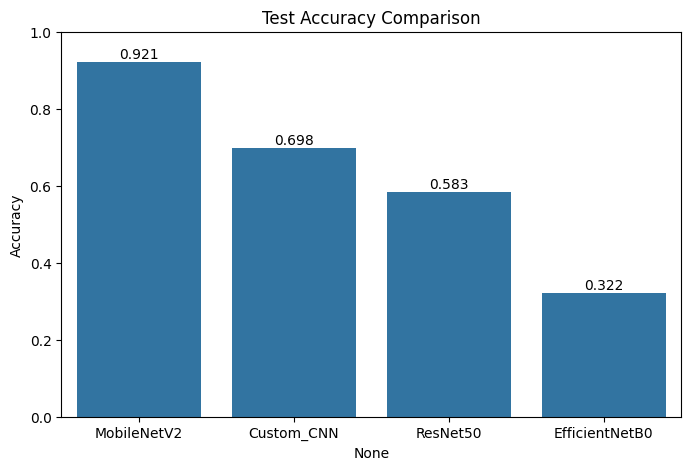

In [22]:
comparison_df = pd.DataFrame(results).T.sort_values('test_accuracy', ascending=False)
print(comparison_df)

plt.figure(figsize=(8, 5))
sns.barplot(x=comparison_df.index, y=comparison_df['test_accuracy'])
plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(comparison_df['test_accuracy']):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.show()

Saving images (12).jpg to images (12).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


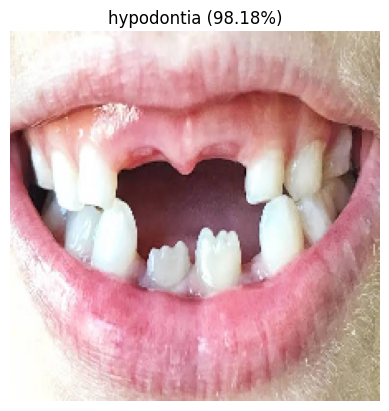

All class probabilities:
  hypodontia: 0.9818
  Gingivitis: 0.0155
  Data caries: 0.0016
  Calculus: 0.0011
  Mouth Ulcer: 0.0000


In [24]:
from google.colab import files
from PIL import Image

# Load MobileNetV2 with its best saved weights
inference_model = build_transfer_model(MobileNetV2, (*IMG_SIZE, 3), num_classes)
inference_model.load_weights("/content/MobileNetV2_best.weights.h5")

# Upload an image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Preprocess
img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
preds = inference_model.predict(img_array)[0]
predicted_class = class_names[np.argmax(preds)]
confidence = np.max(preds)

# Show result
plt.imshow(img)
plt.axis('off')
plt.title(f"{predicted_class} ({confidence:.2%})")
plt.show()

print("All class probabilities:")
for cls, prob in sorted(zip(class_names, preds), key=lambda x: -x[1]):
    print(f"  {cls}: {prob:.4f}")